In [ ]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime

## phase kickback


Figure(370.906x200.667)


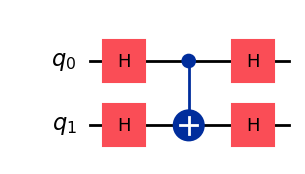

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import math
%matplotlib inline

simulator = AerSimulator()

qc = QuantumCircuit(2)

qc.h([0, 1])

qc.cx(0, 1)

qc.h([0, 1])

print(qc.draw(output='mpl'))


2. T-Gate Phase Kickback Circuit:
Figure(370.906x200.667)


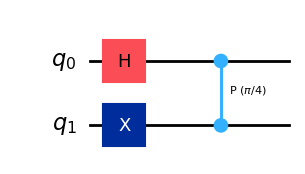

In [ ]:
qc = QuantumCircuit(2)

qc.h(0)
qc.x(1)

qc.cp(math.pi/4, 0, 1)

print(qc.draw(output='mpl'))

qc = transpile(qc, simulator)

## deutsch


Figure(454.517x284.278)
Figure(287.294x284.278)


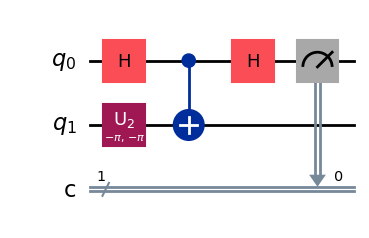

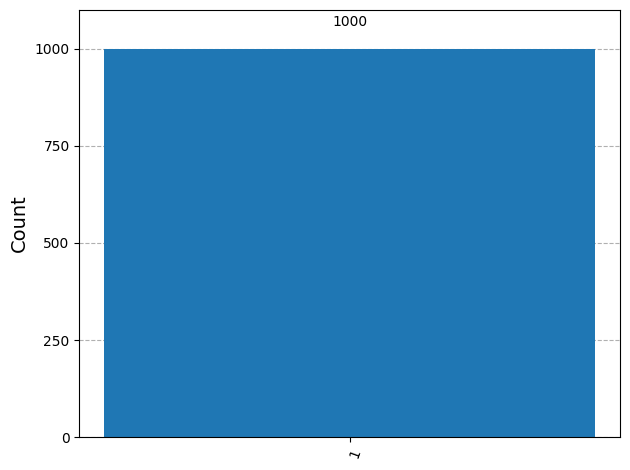

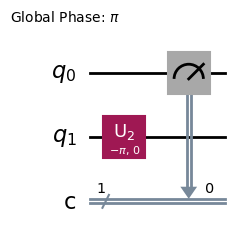

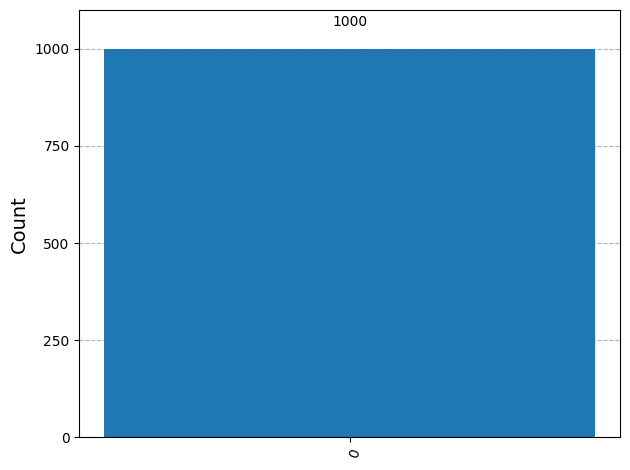

In [4]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
%matplotlib inline

def deutsch(case='balanced'):
    qc = QuantumCircuit(2,1)
    qc.x(1)
    qc.h([0,1])

    if case=='balanced':
        qc.cx(0,1)
    else:
        qc.x(1)     # if f(x)=1 -> keep this line. else comment it
    
    qc.h(0)
    qc.measure(0,0)

    backend = AerSimulator()
    qc = transpile(qc, backend)
    counts = backend.run(qc, shots=1000).result().get_counts()
    
    return qc, counts


# Test Balanced
qc, counts = deutsch('balanced')
print(qc.draw(output='mpl'))
plot_histogram(counts)

# Test Constant
qc, counts = deutsch('constant')
print(qc.draw(output='mpl'))
plot_histogram(counts)

plt.show()

## deutsch jozsa


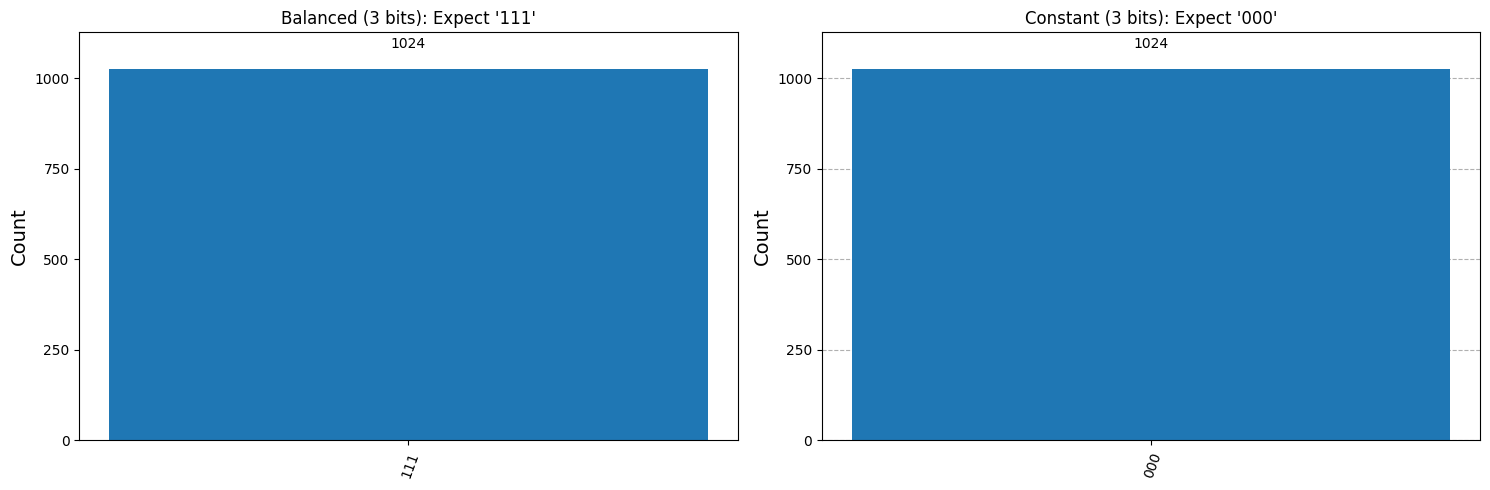

Balanced Deutsch-Jozsa Circuit:
Figure(1040x451.5)


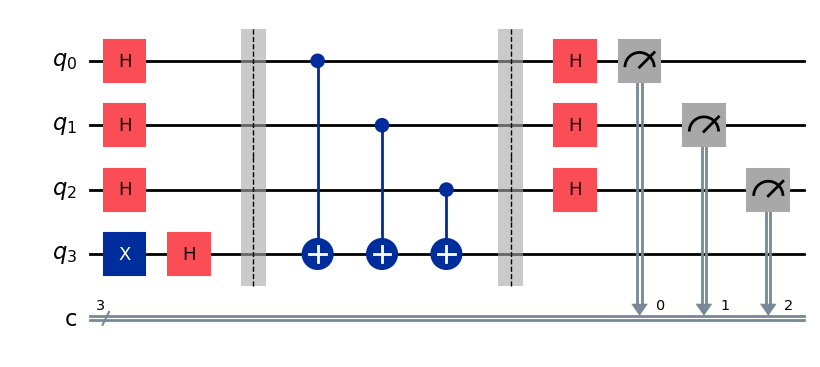

In [ ]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
%matplotlib inline

def deutsch_jozsa(n, case='balanced'):
    qc = QuantumCircuit(n + 1, n)
    
    qc.x(n)          
    qc.h(range(n+1))
    qc.barrier()

    if case == 'balanced':
        for qubit in range(n):
            qc.cx(qubit, n)
    else: 
        qc.x(n)
    
    qc.barrier()

    qc.h(range(n))
    qc.measure(range(n), range(n))
    
    return qc

n_bits = 3
backend = AerSimulator()

qc_balanced = deutsch_jozsa(n_bits, 'balanced')
counts_b = backend.run(transpile(qc_balanced, backend)).result().get_counts()

qc_constant = deutsch_jozsa(n_bits, 'constant')
counts_c = backend.run(transpile(qc_constant, backend)).result().get_counts()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

plot_histogram(counts_b, ax=ax[0])
ax[0].set_title(f"Balanced ({n_bits} bits): Expect '111'")

plot_histogram(counts_c, ax=ax[1])
ax[1].set_title(f"Constant ({n_bits} bits): Expect '000'")

plt.tight_layout()
plt.show()

print("Balanced Deutsch-Jozsa Circuit:")
print(qc_balanced.draw(output='mpl'))